In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [17]:
!wget --quiet https://raw.githubusercontent.com/google-research/bert/master/tokenization.py

In [18]:
df_train=pd.read_csv('train.csv')
df_test=pd.read_csv('test.csv')

In [19]:
print('Training shape ={}'.format(df_train.shape))
print('Testing shape ={}'.format(df_test.shape))

Training shape =(7613, 5)
Testing shape =(3263, 4)


In [20]:
test_dataset.head()

,id,keyword,location,text
0,0,no_keyword,no_location,Just happened a terrible car crash
1,2,no_keyword,no_location,"Heard about #earthquake is different cities, s..."
2,3,no_keyword,no_location,"there is a forest fire at spot pond, geese are..."
3,9,no_keyword,no_location,Apocalypse lighting. #Spokane #wildfires
4,11,no_keyword,no_location,Typhoon Soudelor kills 28 in China and Taiwan


In [21]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [22]:
print(df_test.isnull().sum())
print("=================================")
print(df_test.isnull().sum())

id             0
keyword       26
location    1105
text           0
dtype: int64
id             0
keyword       26
location    1105
text           0
dtype: int64


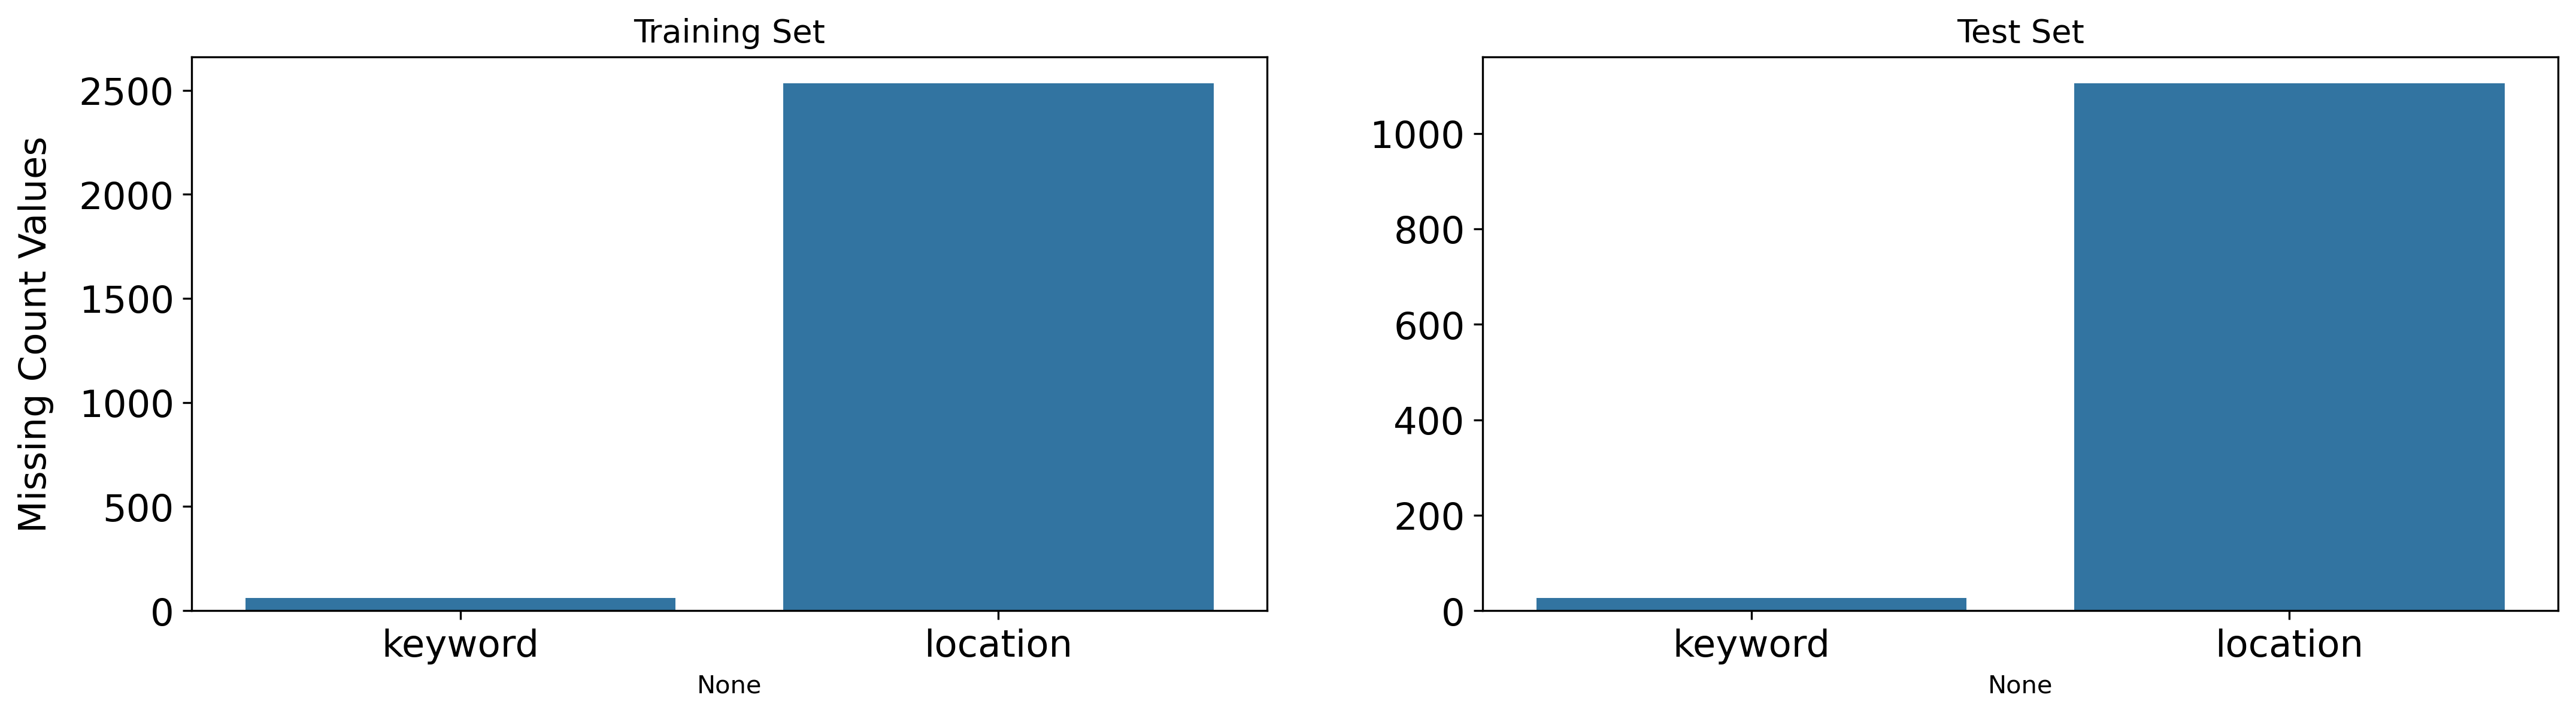

In [23]:
missing_cols=['keyword','location']
fig,axes=plt.subplots(ncols=2,figsize=(17,4),dpi=300)
sns.barplot(x=df_train[missing_cols].isnull().sum().index,y=df_train[missing_cols].isnull().sum().values,ax=axes[0])
sns.barplot(x=df_test[missing_cols].isnull().sum().index,y=df_test[missing_cols].isnull().sum().values,ax=axes[1])
axes[0].set_ylabel('Missing Count Values',size=15,labelpad=10)
axes[0].tick_params(axis='x', labelsize=15)
axes[0].tick_params(axis='y', labelsize=15)
axes[1].tick_params(axis='x', labelsize=15)
axes[1].tick_params(axis='y', labelsize=15)
axes[0].set_title('Training Set', fontsize=13)
axes[1].set_title('Test Set',fontsize=13)
plt.show()

for df in [df_train,df_test]:
    for col in ['keyword','location']:
        df[col]=df[col].fillna(f'no_{col}')



In [25]:
print(f'Number of unique values in keyword = {df_train["keyword"].nunique()} (Training) - {df_test["keyword"].nunique()} (Test)')
print(f'Numbeer of unique values in location={df_test["location"].nunique()} (Training) - {df_test["location"].nunique()} (Test)')


Number of unique values in keyword = 222 (Training) - 222 (Test)
Numbeer of unique values in location=1603 (Training) - 1603 (Test)


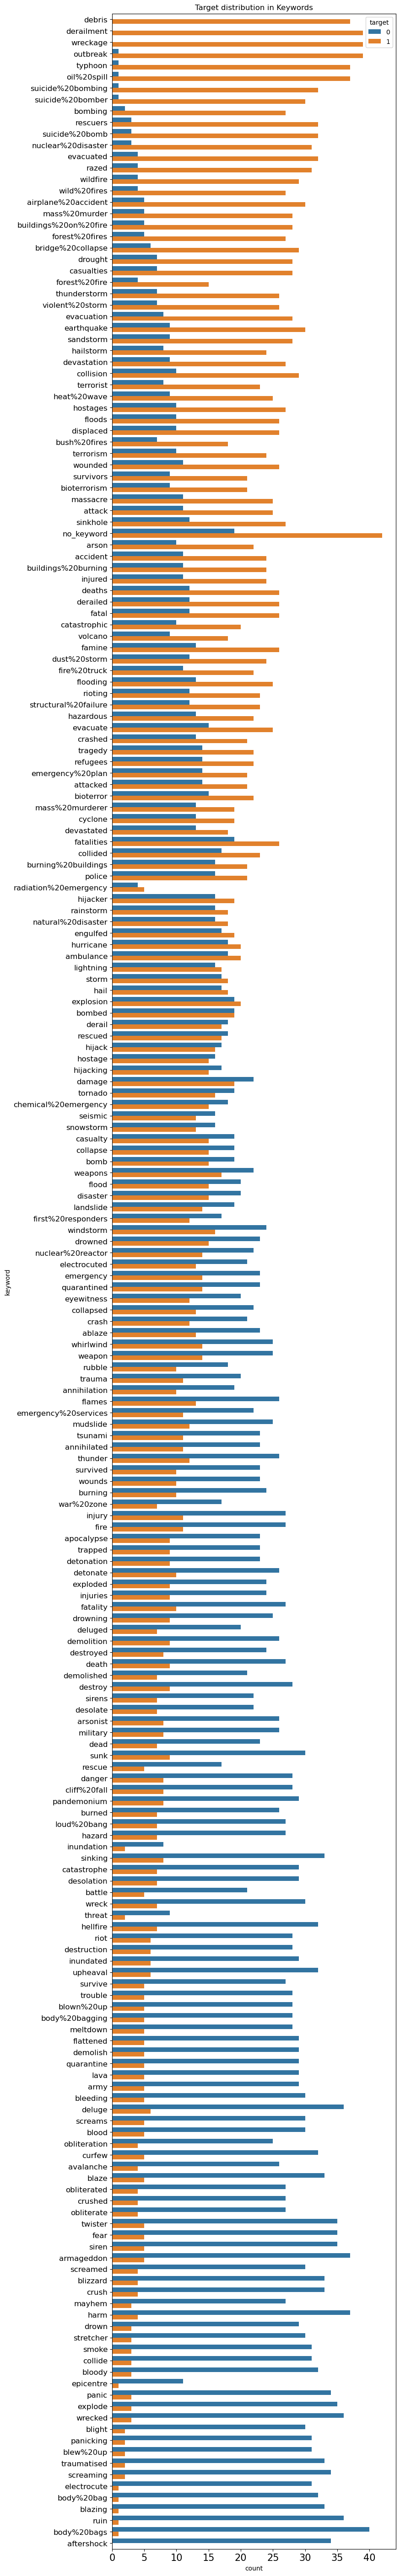

In [34]:
df_train['target_mean']=df_train.groupby('keyword')['target'].transform('mean')
fig=plt.figure(figsize=(8,72),dpi=100)
sns.countplot(y=df_train.sort_values(by='target_mean',ascending=False)['keyword'],hue=df_train.sort_values(by='target_mean',ascending=False)['target'])
plt.tick_params(axis='x',labelsize=15)
plt.tick_params(axis='y',labelsize=12)
plt.title('Target distribution in Keywords')
plt.show()


* word_count
* unique_word_count
* stop_word_count
* url_count
* mean_word_length
* char_count
* punctuation_count
* hashtag_count
* mention_count

In [ ]:
df_train['word_count']=df['train'].apply(lambda x:len(str(x).split()))
df_test['word_count']=df['test'].apply(lambda x:len(str(x).split()))

df_train['unique_word_count']=df['train'].apply(lambda x:len(set(str(x).split())))
df_test['unique_word_count']=df['test'].apply(lambda x:len(set(str(x).split())))

df_train['stop_word_count']